We decided to find the best neighborhood in Pittsburgh by comparing each neigborhood's average daily traffic, median age of death, and ___________.  We decided to use traffic data because it is a good representation of how annoying it is to drive around in an area, so we decided that a low traffic count was good.  We decided to use median age at death because we decided that neighborhoods that allow a person to live longer statistically was better.  We decided to use _______ because _______.

In [21]:
import pandas as pd

traffic_path = 'traffic_final_data.csv'
traffic_data = pd.read_csv(traffic_path)
traffic_data["Rank"] = range(1, len(traffic_data["average_daily_car_traffic"])+1)
traffic_data = traffic_data.rename(columns={"neighborhood":"Neighborhood"})
traffic_data.head(20)

,Neighborhood,average_daily_car_traffic,Rank
0,South Side Flats,115.000000,1
1,Lincoln Place,126.000000,2
2,Lincoln-Lemington-Belmar,195.000000,3
3,Fineview,419.000000,4
4,Allegheny West,477.000000,5
5,New Homestead,666.000000,6
6,Overbrook,777.000000,7
7,Summer Hill,937.000000,8
8,Upper Hill,953.333333,9
9,Central Northside,1189.000000,10


In [16]:
death_data = pd.read_csv('median_age_at_death_submetric.csv')
death_data.head(20)

,Neighborhood,Submetric Score
0,South Shore,1
1,Chateau,2
2,North Shore,3
3,Central Oakland,4
4,East Carnegie,5
5,Allegheny Center,6
6,Swisshelm Park,7
7,New Homestead,8
8,Homewood West,9
9,West End,10


In [32]:
final_df = {}

for index, row in traffic_data.iterrows():
    final_df[row["Neighborhood"]] = row['Rank']

for index, row in death_data.iterrows():
    if row["Neighborhood"] not in final_df.keys():
        final_df[row["Neighborhood"]] = row['Submetric Score']
    final_df[row["Neighborhood"]] += row['Submetric Score']


final_df
final_df = pd.Series(final_df)
final_df = final_df.apply(lambda x: x / 2)
final_df.head()

South Side Flats             0.5
Lincoln Place               16.5
Lincoln-Lemington-Belmar    35.5
Fineview                    29.5
Allegheny West              21.5
dtype: float64

<Axes: >

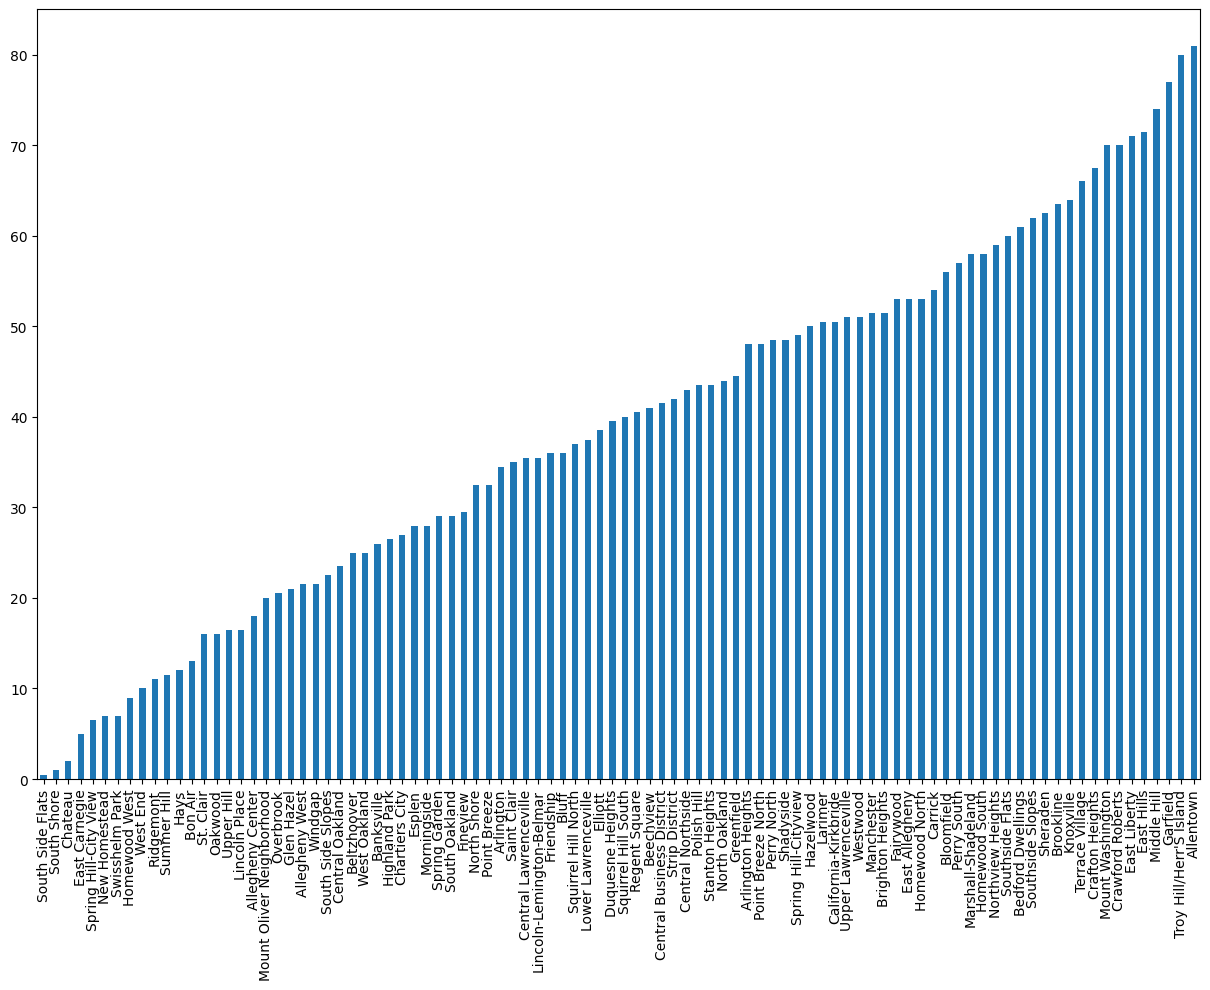

In [36]:
final_df.sort_values(ascending=True).plot(kind='bar', figsize= (15, 10))